# Email / SMS Spam Detection with NLP

**Objective:** Build a Natural Language Processing (NLP) binary classifier that distinguishes spam messages from legitimate ("ham") messages.

**Tech stack:** Python, pandas, scikit-learn (TF-IDF, Naive Bayes / SVM / Logistic Regression), NLTK, WordCloud

---

### Dataset

This notebook uses the classic **SMS Spam Collection Dataset** (5,572 real, hand-labeled SMS messages: 4,825 ham / 747 spam), originally hosted by the UCI Machine Learning Repository and widely mirrored (including on Kaggle as "SMS Spam Collection Dataset"). It was retrieved here from a public GitHub mirror of the original UCI file, so this is the **real, unmodified classic dataset** — no synthetic substitution was needed for this task.

If you'd like to source it yourself: search *"SMS Spam Collection dataset"* on Kaggle.com or at `archive.ics.uci.edu`, download `SMSSpamCollection` (tab-separated: `label\tmessage`), and point `DATA_PATH` below at it.

The same pipeline below works just as well on a labeled *email* spam dataset (e.g. Enron-Spam, SpamAssassin) if you swap in one of those instead — only the loading cell would need to change.


In [1]:
import sys
print(sys.executable)

c:\Users\VENKAT\AppData\Local\Programs\Python\Python314\python.exe


In [2]:
import sys
print(sys.executable)

import wordcloud
print(wordcloud.__version__)

from wordcloud import WordCloud
print("Success")

c:\Users\VENKAT\AppData\Local\Programs\Python\Python314\python.exe
1.9.6
Success


In [3]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
RANDOM_STATE = 42

# One-time NLTK downloads (no-ops if already cached)
for pkg, path in [("stopwords", "corpora/stopwords"), ("wordnet", "corpora/wordnet"), ("omw-1.4", "corpora/omw-1.4")]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(pkg, quiet=True)


## 1. Load the Dataset & Check Class Distribution


In [4]:
DATA_PATH = "SMSSpamCollection.tsv"  # tab-separated: label \t message

df = pd.read_csv(DATA_PATH, sep="\t", header=None, names=["label", "message"])
print("Shape:", df.shape)
df.head(10)


Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Duplicate messages (exact repeats, common with template spam) don't add
# information and can bias the train/test split, so we drop them.
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)


Missing values:
 label      0
message    0
dtype: int64

Duplicate rows: 403
Shape after de-duplication: (5169, 2)


       count  percentage
label                   
ham     4516       87.37
spam     653       12.63


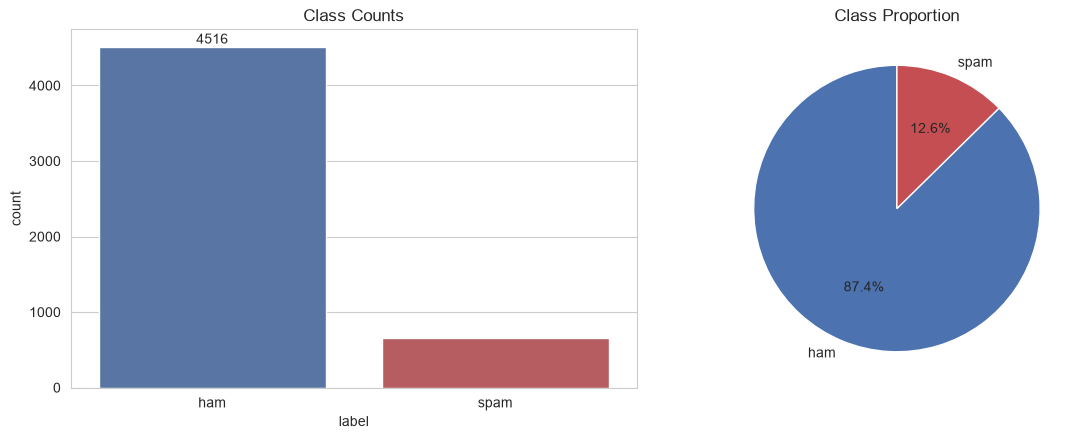

In [6]:
counts = df["label"].value_counts()
percentages = df["label"].value_counts(normalize=True) * 100

dist_summary = pd.DataFrame({"count": counts, "percentage": percentages.round(2)})
print(dist_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df, x="label", ax=axes[0], hue="label", palette={"ham": "#4C72B0", "spam": "#C44E52"}, legend=False)
axes[0].set_title("Class Counts")
axes[0].bar_label(axes[0].containers[0])

axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#C44E52"], startangle=90)
axes[1].set_title("Class Proportion")
plt.tight_layout()
plt.show()


> **Note the imbalance:** ham significantly outnumbers spam (roughly 87% vs. 13%). This is realistic — real inboxes are mostly legitimate mail — but it means **accuracy alone is a misleading metric** here. A model that always predicts "ham" would already score ~87% accuracy while catching zero spam. This is exactly why precision, recall, and F1 (used later) matter more than accuracy for this task.


## 2. Text Preprocessing Pipeline

Steps applied to every message:
1. Lowercase the text.
2. Strip URLs, email addresses, and standalone numbers (spam-specific noise that doesn't generalize as words).
3. Remove punctuation.
4. Tokenize (simple whitespace split).
5. Remove **stopwords** (common words like "the", "is", "and" that carry little discriminative meaning).
6. **Lemmatize** each remaining token (reduce to dictionary base form, e.g. "calling" → "calling", "prizes" → "prize") so that word-form variants collapse into one feature instead of being treated as unrelated tokens.


In [7]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)         # URLs
    text = re.sub(r"\S+@\S+", " ", text)                 # emails
    text = re.sub(r"\d+", " ", text)                     # standalone numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # punctuation
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens
              if tok not in stop_words and len(tok) > 2]
    return " ".join(tokens)

df["clean_message"] = df["message"].apply(preprocess_text)

# sanity check: before vs after
df[["message", "clean_message"]].head(10)


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis great world...
1,Ok lar... Joking wif u oni...,lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win cup final tkts may te...
3,U dun say so early hor... U c already then say...,dun say early hor already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile month entitled update latest colour mob...


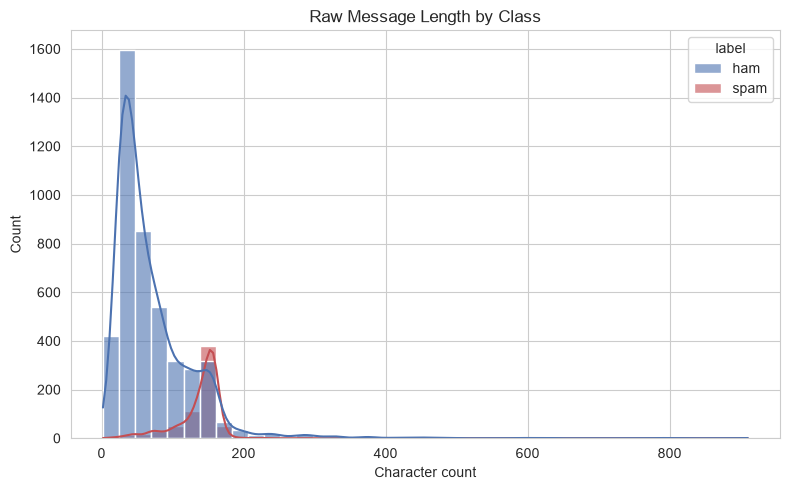

In [8]:
# quick look at message length before/after cleaning
df["raw_len"] = df["message"].str.len()
df["clean_len"] = df["clean_message"].str.len()

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="raw_len", hue="label", bins=40, kde=True,
             palette={"ham": "#4C72B0", "spam": "#C44E52"}, alpha=0.6)
plt.title("Raw Message Length by Class")
plt.xlabel("Character count")
plt.tight_layout()
plt.show()


Spam messages tend to run noticeably longer than ham — they're often templated promotional text packed with calls to action, so message length alone is already mildly predictive.


## 3. Feature Extraction — TF-IDF

**TF-IDF (Term Frequency – Inverse Document Frequency)** converts each cleaned message into a numeric vector, one dimension per vocabulary word. For a word *w* in message *d*:

* **Term Frequency (TF)** — how often *w* appears in *d* (normalized by message length). Common words *within* a message score higher.
* **Inverse Document Frequency (IDF)** — `log(N / (1 + number of messages containing w))`. Words that appear in *many* messages across the whole dataset (like "call" or "hi") get **down-weighted**, while words that are rare across the corpus but concentrated in specific messages (like "urgent!!!" or "claim") get **up-weighted**.
* **TF-IDF score = TF × IDF.**

Intuitively: TF-IDF highlights words that are frequent *in a given message* but *not* generically frequent everywhere — exactly the kind of distinctive vocabulary ("free", "winner", "txt", "claim", "urgent") that separates spam from ordinary conversation.


In [9]:
label_map = {"ham": 0, "spam": 1}
df["label_bin"] = df["label"].map(label_map)

X = df["clean_message"]
y = df["label_bin"]


## 4. Train / Test Split

`stratify=y` keeps the ~87/13 ham/spam ratio consistent between train and test sets, which matters given the class imbalance noted above.


In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train_text.shape[0])
print("Test size:", X_test_text.shape[0])
print("Train spam %:", round(y_train.mean() * 100, 2))
print("Test spam %:", round(y_test.mean() * 100, 2))


Train size: 4135
Test size: 1034
Train spam %: 12.62
Test spam %: 12.67


In [11]:
# Fit TF-IDF on the TRAINING set only, then transform both sets --
# fitting on test data would leak information about the test vocabulary.
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))


TF-IDF matrix shape (train): (4135, 3000)
Vocabulary size: 3000


## 5. Train Classifiers

Two models are trained and compared:
1. **Multinomial Naive Bayes** — the traditional, very strong baseline for text classification; assumes word counts follow a multinomial distribution conditioned on the class, and works well with TF-IDF/count features.
2. **Linear SVM** (`LinearSVC`) — a discriminative margin-based classifier that often performs excellently on high-dimensional sparse text data.

*(Logistic Regression is also included as a second alternative for a fuller comparison.)*


In [12]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    fitted_models[name] = model
    print(f"Trained: {name}")


Trained: Multinomial Naive Bayes
Trained: Logistic Regression
Trained: Linear SVM


## 6. Evaluation: Accuracy, Precision, Recall, F1, Confusion Matrix


In [14]:
results = []
predictions = {}

for name, model in fitted_models.items():
    preds = model.predict(X_test_tfidf)
    predictions[name] = preds
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-score": f1_score(y_test, preds),
    })

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-score
0,Linear SVM,0.977756,0.950000,0.870229,0.908367
1,Multinomial Naive Bayes,0.974855,1.000000,0.801527,0.889831
2,Logistic Regression,0.959381,0.958763,0.709924,0.815789


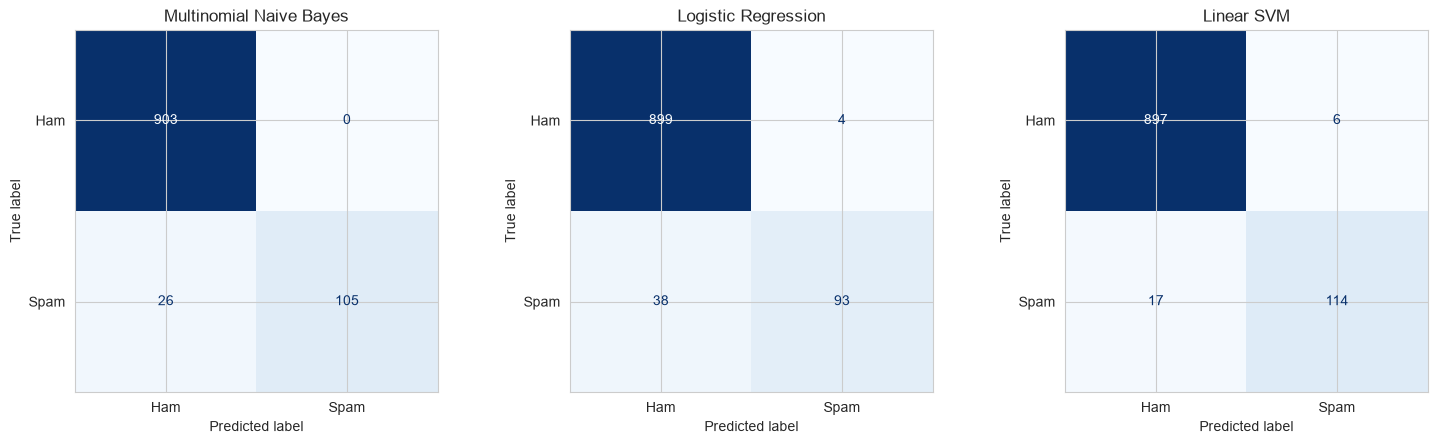

In [15]:
fig, axes = plt.subplots(1, len(fitted_models), figsize=(5 * len(fitted_models), 4.5))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [16]:
for name, preds in predictions.items():
    print(f"=== {name} ===")
    print(classification_report(y_test, preds, target_names=["Ham", "Spam"]))


=== Multinomial Naive Bayes ===
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       903
        Spam       1.00      0.80      0.89       131

    accuracy                           0.97      1034
   macro avg       0.99      0.90      0.94      1034
weighted avg       0.98      0.97      0.97      1034

=== Logistic Regression ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.96      0.71      0.82       131

    accuracy                           0.96      1034
   macro avg       0.96      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034

=== Linear SVM ===
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.95      0.87      0.91       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      

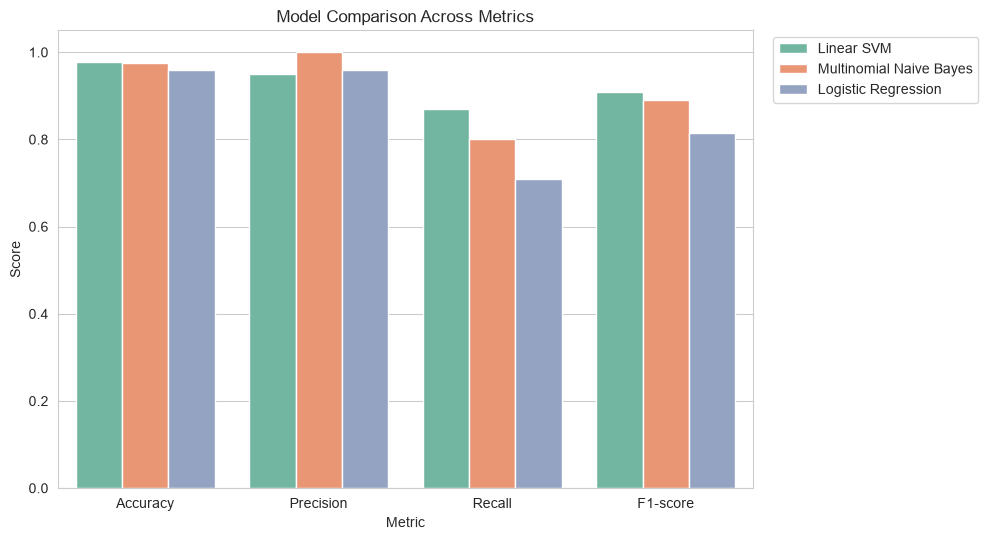

In [17]:
melted = results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
                          var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5.5))
sns.barplot(data=melted, x="Metric", y="Score", hue="Model", palette="Set2")
plt.ylim(0, 1.05)
plt.title("Model Comparison Across Metrics")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 7. Why Is Recall Particularly Important for Spam Detection?

In this binary task, **recall** (for the *spam* class) asks: *of all the actual spam messages, how many did the model successfully catch?* It's calculated as `TP / (TP + FN)` — true positives over all real spam, i.e. it penalizes **false negatives** (spam that slips through into the inbox undetected).

**Precision**, by contrast, asks: *of everything the model flagged as spam, how much really was spam?* It penalizes **false positives** (a legitimate email wrongly marked as spam).

For spam filtering these two error types are **not equally costly**:

- A **false negative** (missed spam) means a phishing link, scam, or malware attachment lands directly in the user's inbox — with real financial, security, or fraud risk if the user is misled.
- A **false positive** (ham misclassified as spam) is annoying — a legitimate email gets buried in a spam folder — but it's a much smaller harm, and users routinely check spam folders to recover falsely-flagged mail.

Because a *missed spam email* can cause real harm (fraud, malware, credential theft) while a *false alarm* mostly costs a bit of inconvenience, spam filters are generally tuned to prioritize **recall** on the spam class — catching as much spam as possible — while still keeping precision high enough that the false-positive rate doesn't become disruptive. In practice this is a genuine trade-off (raising recall by loosening the decision threshold usually lowers precision), which is why **F1-score** — the harmonic mean of precision and recall — is often reported alongside them: it summarizes how well a model balances *catching spam* against *not burying real mail*.

Looking at the results above: the model with the lowest spam recall would let the most fraudulent/malicious messages through unflagged — that's the practical risk to watch for, even if its overall accuracy looks fine (recall accuracy's blind spot to class imbalance from Section 1).


## 8. Bonus: WordClouds for Spam vs. Ham


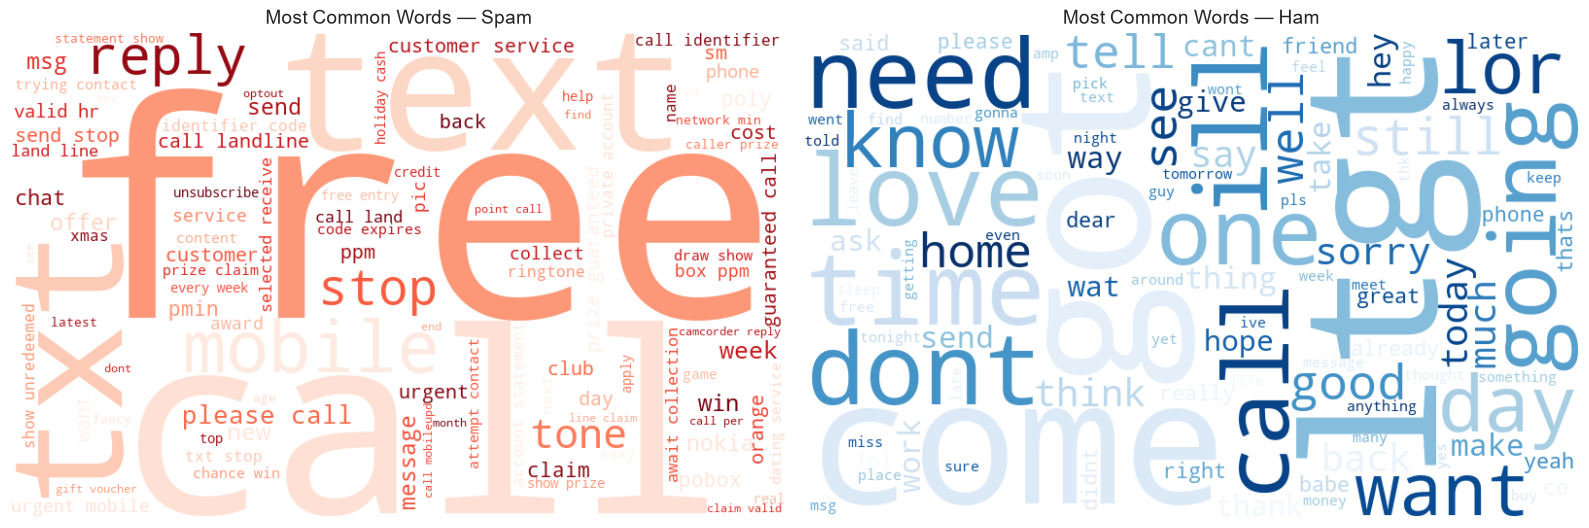

In [19]:
from wordcloud import WordCloud

spam_text = " ".join(df.loc[df["label"] == "spam", "clean_message"])
ham_text = " ".join(df.loc[df["label"] == "ham", "clean_message"])

wc_spam = WordCloud(width=800, height=500, background_color="white",
                     colormap="Reds", max_words=100).generate(spam_text)
wc_ham = WordCloud(width=800, height=500, background_color="white",
                    colormap="Blues", max_words=100).generate(ham_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(wc_spam, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Most Common Words — Spam", fontsize=14)

axes[1].imshow(wc_ham, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Most Common Words — Ham", fontsize=14)

plt.tight_layout()
plt.show()


Spam vocabulary skews toward urgency and reward cues ("free", "call", "win", "claim", "urgent", "text", "prize"), while ham vocabulary looks like ordinary conversational language ("get", "come", "know", "love", "day", "time") — this visual gap is exactly what the TF-IDF + classifier pipeline is exploiting numerically.


## 9. Summary

* Loaded the real SMS Spam Collection dataset (5,572 messages; ~87% ham / ~13% spam) and confirmed the class imbalance up front, which is why accuracy alone isn't trusted as the primary metric.
* Built a text preprocessing pipeline: lowercasing, URL/email/number stripping, punctuation removal, stopword removal, and lemmatization.
* Extracted TF-IDF features (unigrams + bigrams, 3,000 features) fit only on the training split to avoid leakage.
* Trained and compared three classifiers — Multinomial Naive Bayes, Logistic Regression, and Linear SVM — using accuracy, precision, recall, F1, and confusion matrices.
* Discussed why **recall on the spam class** is the metric to prioritize in this domain, since missed spam (false negatives) carries higher real-world risk than a false alarm.
* Visualized the distinguishing vocabulary of spam vs. ham with WordClouds.

**Next steps to try:** hyperparameter tuning (`GridSearchCV` over `alpha` for NB or `C` for SVM/LogReg), character n-gram TF-IDF (robust to spam's deliberate misspellings like "fr33"), calibrating the decision threshold to explicitly trade precision for recall, or trying a more expressive model (e.g. gradient-boosted trees on TF-IDF, or a small transformer).
